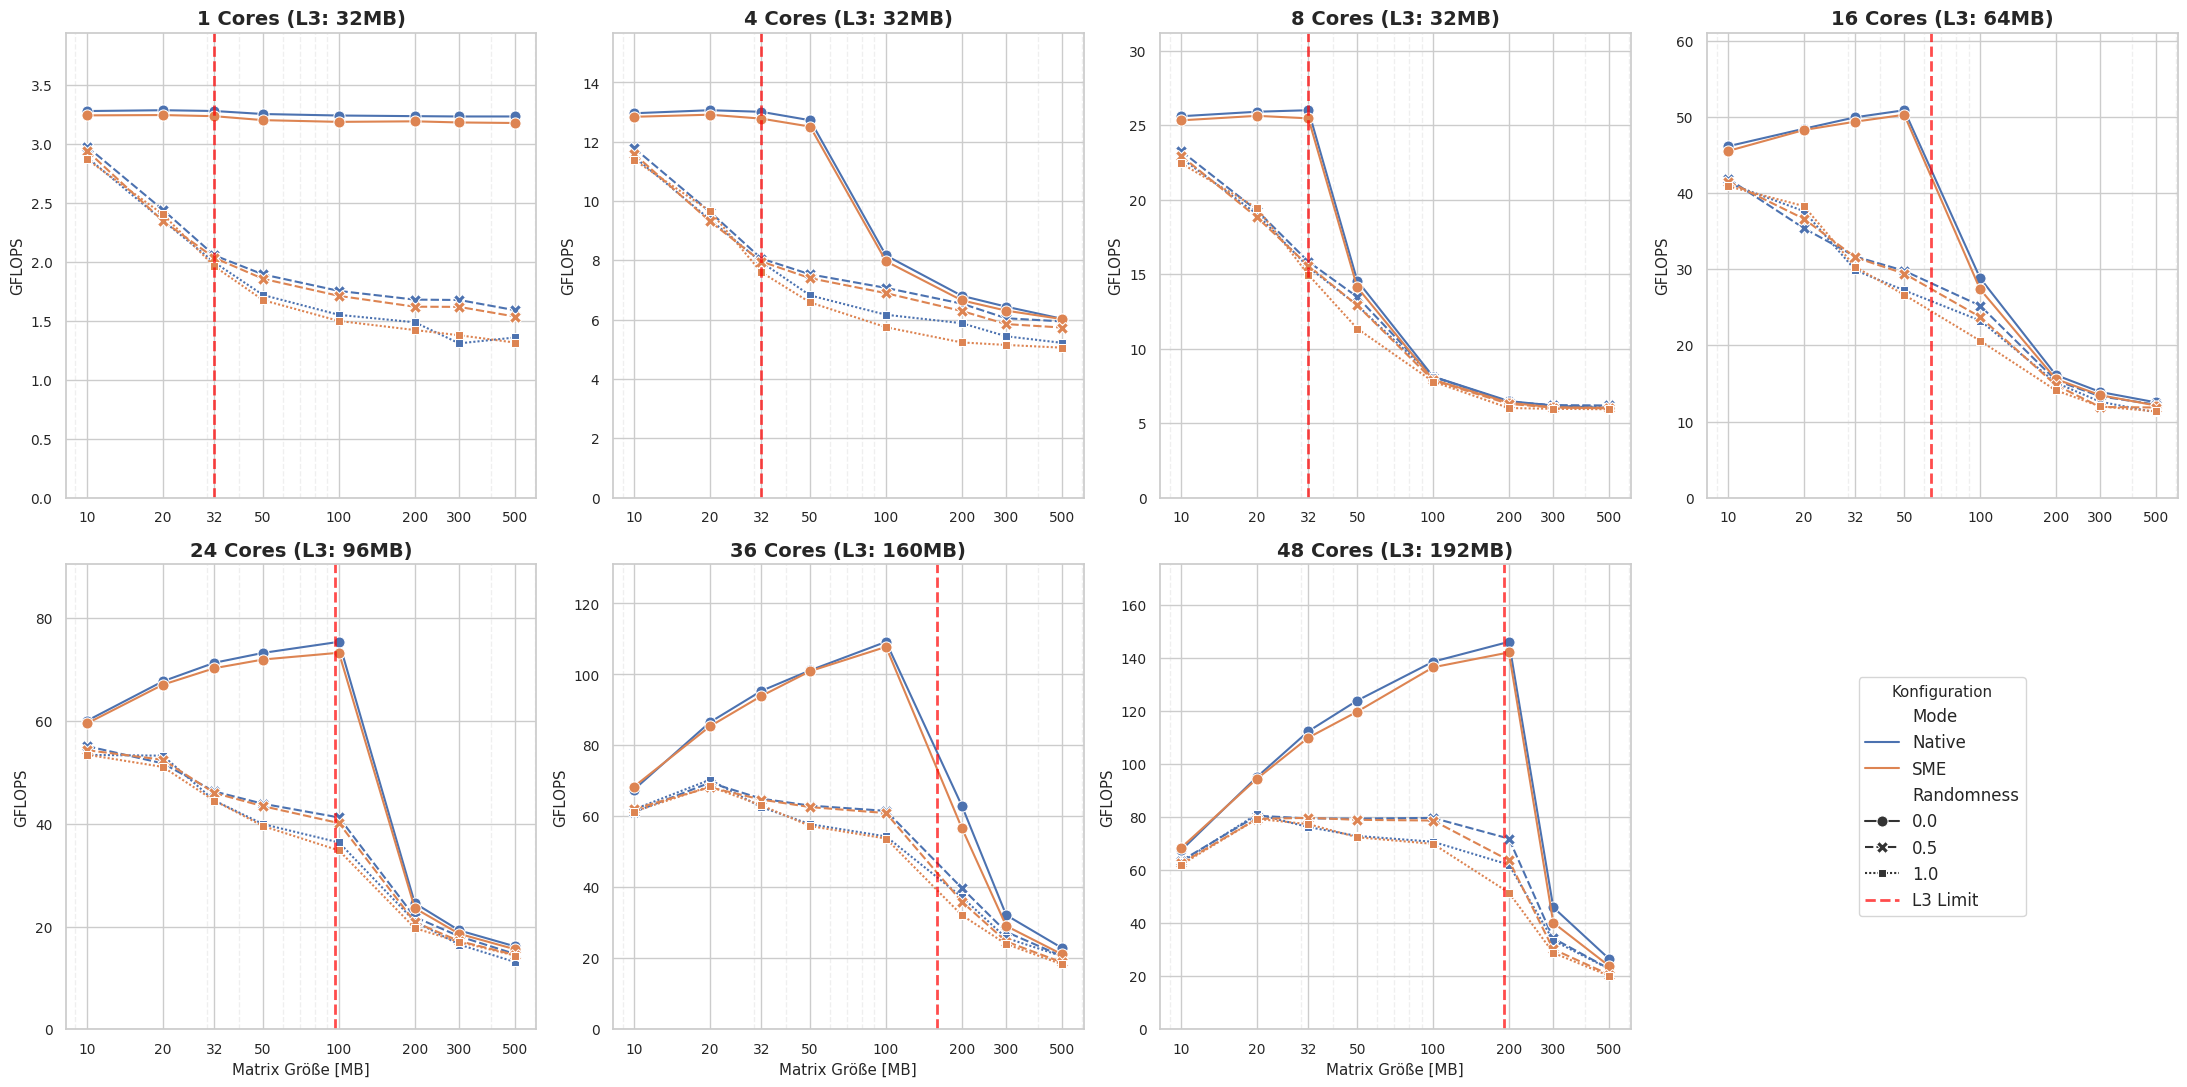

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Pfade zu deinen CSVs
files = {
    'Native': '/home/mengelsl/MA-bench-framework/outputs_testing/native/summary_final.csv',
    'SME': '/home/mengelsl/MA-bench-framework/outputs_testing/sme/summary_final.csv', 
}

def get_n(f):
    m = re.search(r'N(\d+)', f)
    return int(m.group(1)) if m else 0

def get_rand(f):
    m = re.search(r'(\d)-(\d)', f)
    return float(f"{m.group(1)}.{m.group(2)}") if m else 0.0

def load_and_process(label, path):
    if not os.path.exists(path): return None
    df = pd.read_csv(path)
    df['Mode'] = label
    df['N'] = df['Matrix'].apply(get_n)
    df['Randomness'] = df['Matrix'].apply(get_rand)
    df['MB'] = (df['N'] / 2750).round().astype(int)
    return df

# Daten laden
df_list = [load_and_process(l, p) for l, p in files.items()]
df = pd.concat([d for d in df_list if d is not None])
df_median = df.groupby(['MB', 'Randomness', 'Cores', 'Mode'])['Gflops'].median().reset_index()

# Plotting in 2x4 Grid
sns.set_theme(style="whitegrid", font_scale=0.9)
unique_cores = sorted(df_median['Cores'].unique())

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

# Definierte Ticks für die X-Achse (deine Messpunkte)
x_ticks = [10, 20, 32, 50, 100, 200, 300, 500]

for idx, core in enumerate(unique_cores):
    ax = axes[idx]
    subset_core = df_median[df_median['Cores'] == core].sort_values('MB')
    
    # Dynamische Cache-Linie (32MB pro 8 Cores)
    l3_capacity = np.ceil(core / 8) * 32
    
    # WICHTIG: Erst die Skalierung auf LOG setzen, dann plotten
    ax.set_xscale('log')
    
    sns.lineplot(data=subset_core, x='MB', y='Gflops', 
                 hue='Mode', style='Randomness', 
                 markers=True, markersize=8, ax=ax, legend=(idx == 0))
    
    # Cache-Linie einzeichnen
    ax.axvline(x=l3_capacity, color='red', linestyle='--', alpha=0.7, linewidth=2, label='L3 Limit')
    
    # Achsen-Beschriftung entzerren
    ax.set_xticks(x_ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    
    ax.set_title(f'{core} Cores (L3: {int(l3_capacity)}MB)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Matrix Größe [MB]' if idx >= 4 else '')
    ax.set_ylabel('GFLOPS')
    
    # Y-Achse optimieren (Individuell pro Plot)
    ax.set_ylim(0, subset_core['Gflops'].max() * 1.2)
    
    # Gitternetz für Log-Skala verbessern
    ax.grid(True, which="minor", ls="--", alpha=0.3)

# Legende in den freien Slot (Plot 8) schieben
if len(unique_cores) < len(axes):
    for i in range(len(unique_cores), len(axes)):
        axes[i].axis('off')
    
    handles, labels = axes[0].get_legend_handles_labels()
    # Wir filtern doppelte Einträge in der Legende
    by_label = dict(zip(labels, handles))
    axes[-1].legend(by_label.values(), by_label.keys(), loc='center', title='Konfiguration', fontsize=12)
    axes[0].get_legend().remove()

plt.tight_layout()
plt.show()

In [2]:
# Neue Cell: Pivot-Tabelle mit Relativem Jitter (CV)
import pandas as pd

# 1. Stats berechnen
stats = df.groupby(['MB', 'Randomness', 'Cores', 'Mode'])['Gflops'].agg(['median', 'std']).reset_index()

# 2. Pivot
table_view = stats.pivot_table(
    index=['Cores', 'MB', 'Randomness'], 
    columns='Mode', 
    values=['median', 'std']
)
table_view.columns = [f'{mode}_std' if stat == 'std' else mode for stat, mode in table_view.columns]
table_view = table_view.reset_index()

# 3. Relativen Jitter (CV) in % berechnen für fairen Vergleich
for m in ['Native', 'SME', 'SEV']:
    if m in table_view.columns and f'{m}_std' in table_view.columns:
        table_view[f'{m}_Jitter_%'] = (table_view[f'{m}_std'] / table_view[m]) * 100

# 4. Overhead-Berechnung
if 'Native' in table_view.columns:
    for m in ['SME', 'SEV']:
        if m in table_view.columns:
            table_view[f'{m}_Loss_%'] = (1 - (table_view[m] / table_view['Native'])) * 100

# 5. Spalten ordnen
ordered_cols = ['Cores', 'MB', 'Randomness']
for m in ['Native', 'SME', 'SEV']:
    if m in table_view.columns:
        # Wir zeigen Wert und den RELATIVEN Jitter daneben
        ordered_cols += [m, f'{m}_Jitter_%']

ordered_cols += [c for c in table_view.columns if 'Loss' in c]
table_view = table_view[ordered_cols]

# 6. Styling
format_map = {c: '{:.2f}' for c in table_view.columns if c not in ['Cores', 'MB', 'Randomness']}
for c in table_view.columns:
    if 'Loss' in c or 'Jitter' in c: format_map[c] = '{:.2f}%'

styled = table_view.style.format(format_map).background_gradient(
    cmap='Reds', subset=[c for c in table_view.columns if 'Loss' in c]
).background_gradient(
    cmap='YlGnBu', subset=[c for c in table_view.columns if 'Jitter' in c]
)

display(styled)

,Cores,MB,Randomness,Native,Native_Jitter_%,SME,SME_Jitter_%,SME_Loss_%
0,1,10,0.000000,3.29,0.10%,3.24,0.18%,1.36%
1,1,10,0.500000,2.98,0.43%,2.94,0.60%,1.41%
2,1,10,1.000000,2.90,0.36%,2.87,0.17%,1.09%
3,1,21,0.000000,3.29,0.05%,3.25,0.07%,1.21%
4,1,21,0.500000,2.36,1.46%,2.31,0.47%,1.97%
5,1,21,1.000000,2.40,4.86%,2.32,4.05%,3.29%
6,1,42,0.000000,3.26,0.06%,3.21,0.04%,1.51%
7,1,42,0.500000,1.95,0.32%,1.91,0.43%,2.07%
8,1,42,1.000000,1.80,0.26%,1.76,0.72%,1.97%
9,1,84,0.000000,3.24,0.04%,3.19,0.06%,1.66%


In [26]:
import numpy as np

# t-Wert für n=7 @ 95% Konfidenz
T_VAL = 2.447
TARGET_ACCURACY = 0.008

recommendations = {}

for m in ['Native', 'SME', 'SEV']:
    jitter_col = f'{m}_Jitter_%'
    if jitter_col in table_view.columns:
        # CV ist Jitter/100
        avg_cv = table_view[jitter_col].mean() / 100
        # Formel: n = ((t * CV) / accuracy)^2
        n_req = ((T_VAL * avg_cv) / TARGET_ACCURACY)**2
        recommendations[m] = int(np.ceil(n_req))

print("--- AGGREGIERTE RUN-EMPFEHLUNG (Ziel: 2% Genauigkeit) ---")
for mode, runs in recommendations.items():
    status = "OK" if runs <= 7 else "ERHÖHEN!"
    print(f"Mode: {mode:6} | Aktueller Jitter (Ø): {table_view[f'{mode}_Jitter_%'].mean():.2f}% | Benötigte Runs: {runs:2} | Status: {status}")

# Finale Ansage
final_n = max(recommendations.values()) if recommendations else 7
print(f"\n>> EMPFEHLUNG FÜR DEN NÄCHSTEN BENCHMARK: {max(7, final_n)} RUNS <<")

--- AGGREGIERTE RUN-EMPFEHLUNG (Ziel: 2% Genauigkeit) ---
Mode: Native | Aktueller Jitter (Ø): 0.86% | Benötigte Runs:  7 | Status: OK
Mode: SME    | Aktueller Jitter (Ø): 0.90% | Benötigte Runs:  8 | Status: ERHÖHEN!
Mode: SEV    | Aktueller Jitter (Ø): 0.98% | Benötigte Runs:  9 | Status: ERHÖHEN!

>> EMPFEHLUNG FÜR DEN NÄCHSTEN BENCHMARK: 9 RUNS <<


--- Durchschnittliche Performance-Abweichung pro Run-Nummer ---


,Run,mean,std,count,Abweichung_%
0,1,0.9991,0.0117,504,-0.09%
1,2,0.9996,0.0119,504,-0.04%
2,3,0.9984,0.0140,504,-0.16%
3,4,1.0003,0.0122,504,+0.03%
4,5,0.9986,0.0148,504,-0.14%
5,6,0.9988,0.0165,504,-0.12%
6,7,0.9992,0.0127,504,-0.08%


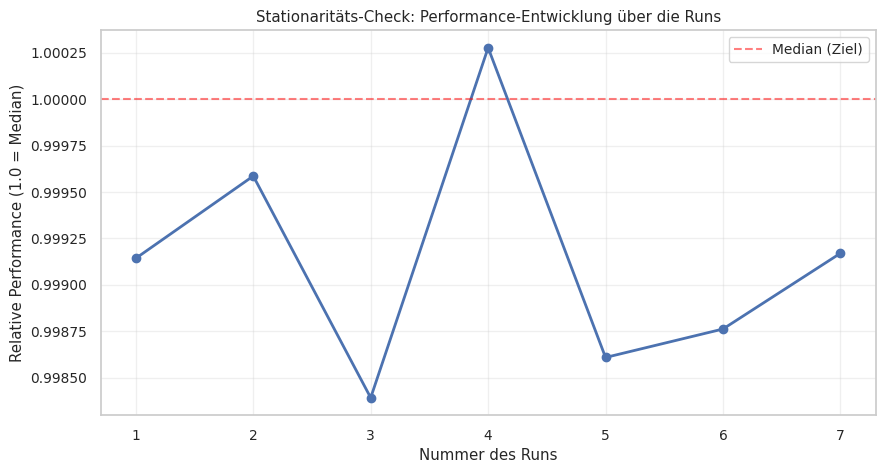

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Normierung: Jeder Run wird im Verhältnis zum Median seiner Gruppe gesetzt
# (Matrix, Cores, Mode)
group_cols = ['MB', 'Randomness', 'Cores', 'Mode']
group_medians = df.groupby(group_cols)['Gflops'].transform('median')
df['Gflops_Relative'] = df['Gflops'] / group_medians

# 2. Aggregation über alle Messungen hinweg: Wie verhält sich Run X im Schnitt?
run_analysis = df.groupby('Run')['Gflops_Relative'].agg(['mean', 'std', 'count']).reset_index()

# Umrechnung in Prozent Abweichung vom Median (Median = 100%)
run_analysis['Abweichung_%'] = (run_analysis['mean'] - 1) * 100

print("--- Durchschnittliche Performance-Abweichung pro Run-Nummer ---")
display(run_analysis.style.format({
    'mean': '{:.4f}', 
    'std': '{:.4f}', 
    'Abweichung_%': '{:+.2f}%'
}))

# 3. Visualisierung (Der "Warm-up" Plot)
plt.figure(figsize=(10, 5))
plt.plot(run_analysis['Run'], run_analysis['mean'], marker='o', linestyle='-', linewidth=2)
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Median (Ziel)')
plt.title('Stationaritäts-Check: Performance-Entwicklung über die Runs')
plt.xlabel('Nummer des Runs')
plt.ylabel('Relative Performance (1.0 = Median)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()